# Exploratory Data Analysis

### Univariate Analysis

Under the univariate analysis section, three main analysis were done:
- Summary statistics
- Histograms with kernel density plots
- Box plots

Key findings from Univariate analysis:
1. Positive Skew:
- The summary statistics and histograms reveal that most variables, with the exception of relative humidity, are positively skewed. 
- API displays a noticeable skew and deviates from a Gaussian (normal) distribution, suggesting that linear regression models may not be suitable for this dataset, as they typically assume normally distributed residuals and linear relationships.
- The skewness values of PM10, PM2.5, and SO₂ are extremely high (4.16,	5.38, and	6.77, respectively). This indicates that the dataset contains significant outliers or rare high-concentration events.
2. Symmetry:
- Variables such as Relative Humidity and Ambient Temperature are nearly symmetric, with skewness values of -0.62 and 0.48, respectively, reflecting expected meteorological patterns.


Outlier analysis revealed that nearly 10% of the data would be excluded if rows with extreme API values were removed, as highlighted in the boxplot. However, since this study aims to capture the full variability of API, including rare but significant events like haze, outliers have been retained.

This approach ensures the dataset accurately reflects real-world conditions in Malaysia, where such extreme events play a critical role in air quality monitoring and prediction. However, the inclusion of these outliers introduces challenges for certain machine learning algorithms due to the skewed data distribution.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To render plots after code
%matplotlib inline

# To upload preprocessed dataset
df = pd.read_csv('../data/interim/preprocessed_df.csv')

In [2]:
# @title
# Descriptive Statistics for Pollutants and Air Conditions
from scipy.stats import skew

# Define variables for analysis
var_sub = ['API',
          'PM10 1H (µg/m3)',
          'PM2.5 1H (µg/m3)',
          'SO2 1H (ppm)',
          'NO2 1H (ppm)',
          'O3 1H (ppm)',
          'CO 1H (ppm)',
          'WIND DIRECTION 1H (°)',
          'WIND SPEED 1H (m/s)',
          'RELATIVE HUMIDITY 1H (%)',
          'Ambient Temperature 1H (°c)']

# Define data for summary
df_sub = df[var_sub]

# Add summary statistics to dataframe
descriptive_stats = pd.DataFrame()
descriptive_stats['Mean'] = df_sub.mean()
descriptive_stats['Median'] = df_sub.median()
descriptive_stats['Mode'] = df_sub.mode().iloc[0] #iloc to select first mode
descriptive_stats['Standard Deviation'] = df_sub.std()
descriptive_stats['Min'] = df_sub.min()
descriptive_stats['Max'] = df_sub.max()
descriptive_stats['Skew'] = df_sub.skew()

# Transpose Dataframe (Switch columns and row index)
descriptive_stats = descriptive_stats.T

# Display summary statistics
descriptive_stats.style.format({
    'API': "{:.2f}",
    'PM10 1H (µg/m3)': "{:.2f}",
    'PM2.5 1H (µg/m3)': "{:.2f}",
    'SO2 1H (ppm)': "{:.2E}",
    'NO2 1H (ppm)': "{:.2E}",
    'O3 1H (ppm)': "{:.2E}",
    'CO 1H (ppm)': "{:.2f}",
    'WIND DIRECTION 1H (°)': "{:.2f}",
    'WIND SPEED 1H (m/s)': "{:.2f}",
    'RELATIVE HUMIDITY 1H (%)': "{:.2f}",
    'Ambient Temperature 1H (°c)': "{:.2f}"
    })


,API,PM10 1H (µg/m3),PM2.5 1H (µg/m3),SO2 1H (ppm),NO2 1H (ppm),O3 1H (ppm),CO 1H (ppm),WIND DIRECTION 1H (°),WIND SPEED 1H (m/s),RELATIVE HUMIDITY 1H (%),Ambient Temperature 1H (°c)
Mean,58.68,27.76,19.38,1.32E-03,1.23E-02,1.67E-02,0.71,157.66,1.01,81.10,27.80
Median,58.00,25.17,17.23,1.20E-03,1.09E-02,1.11E-02,0.67,137.49,0.81,83.65,27.18
Mode,55.00,26.51,15.57,9.00E-04,7.10E-03,7.00E-04,0.66,90.00,0.54,100.00,25.57
Standard Deviation,12.50,15.41,12.47,9.69E-04,7.95E-03,1.69E-02,0.35,97.90,0.74,12.84,3.04
Min,17.00,0.11,0.00,0.00E+00,0.00E+00,-3.54E-06,0.04,0.00,0.00,33.32,20.44
Max,169.00,940.84,905.11,4.40E-02,1.57E-01,1.35E-01,6.74,359.96,8.71,100.00,42.55
Skew,1.51,4.16,5.38,6.77E+00,1.37E+00,1.35E+00,1.07,0.42,2.01,-0.62,0.48


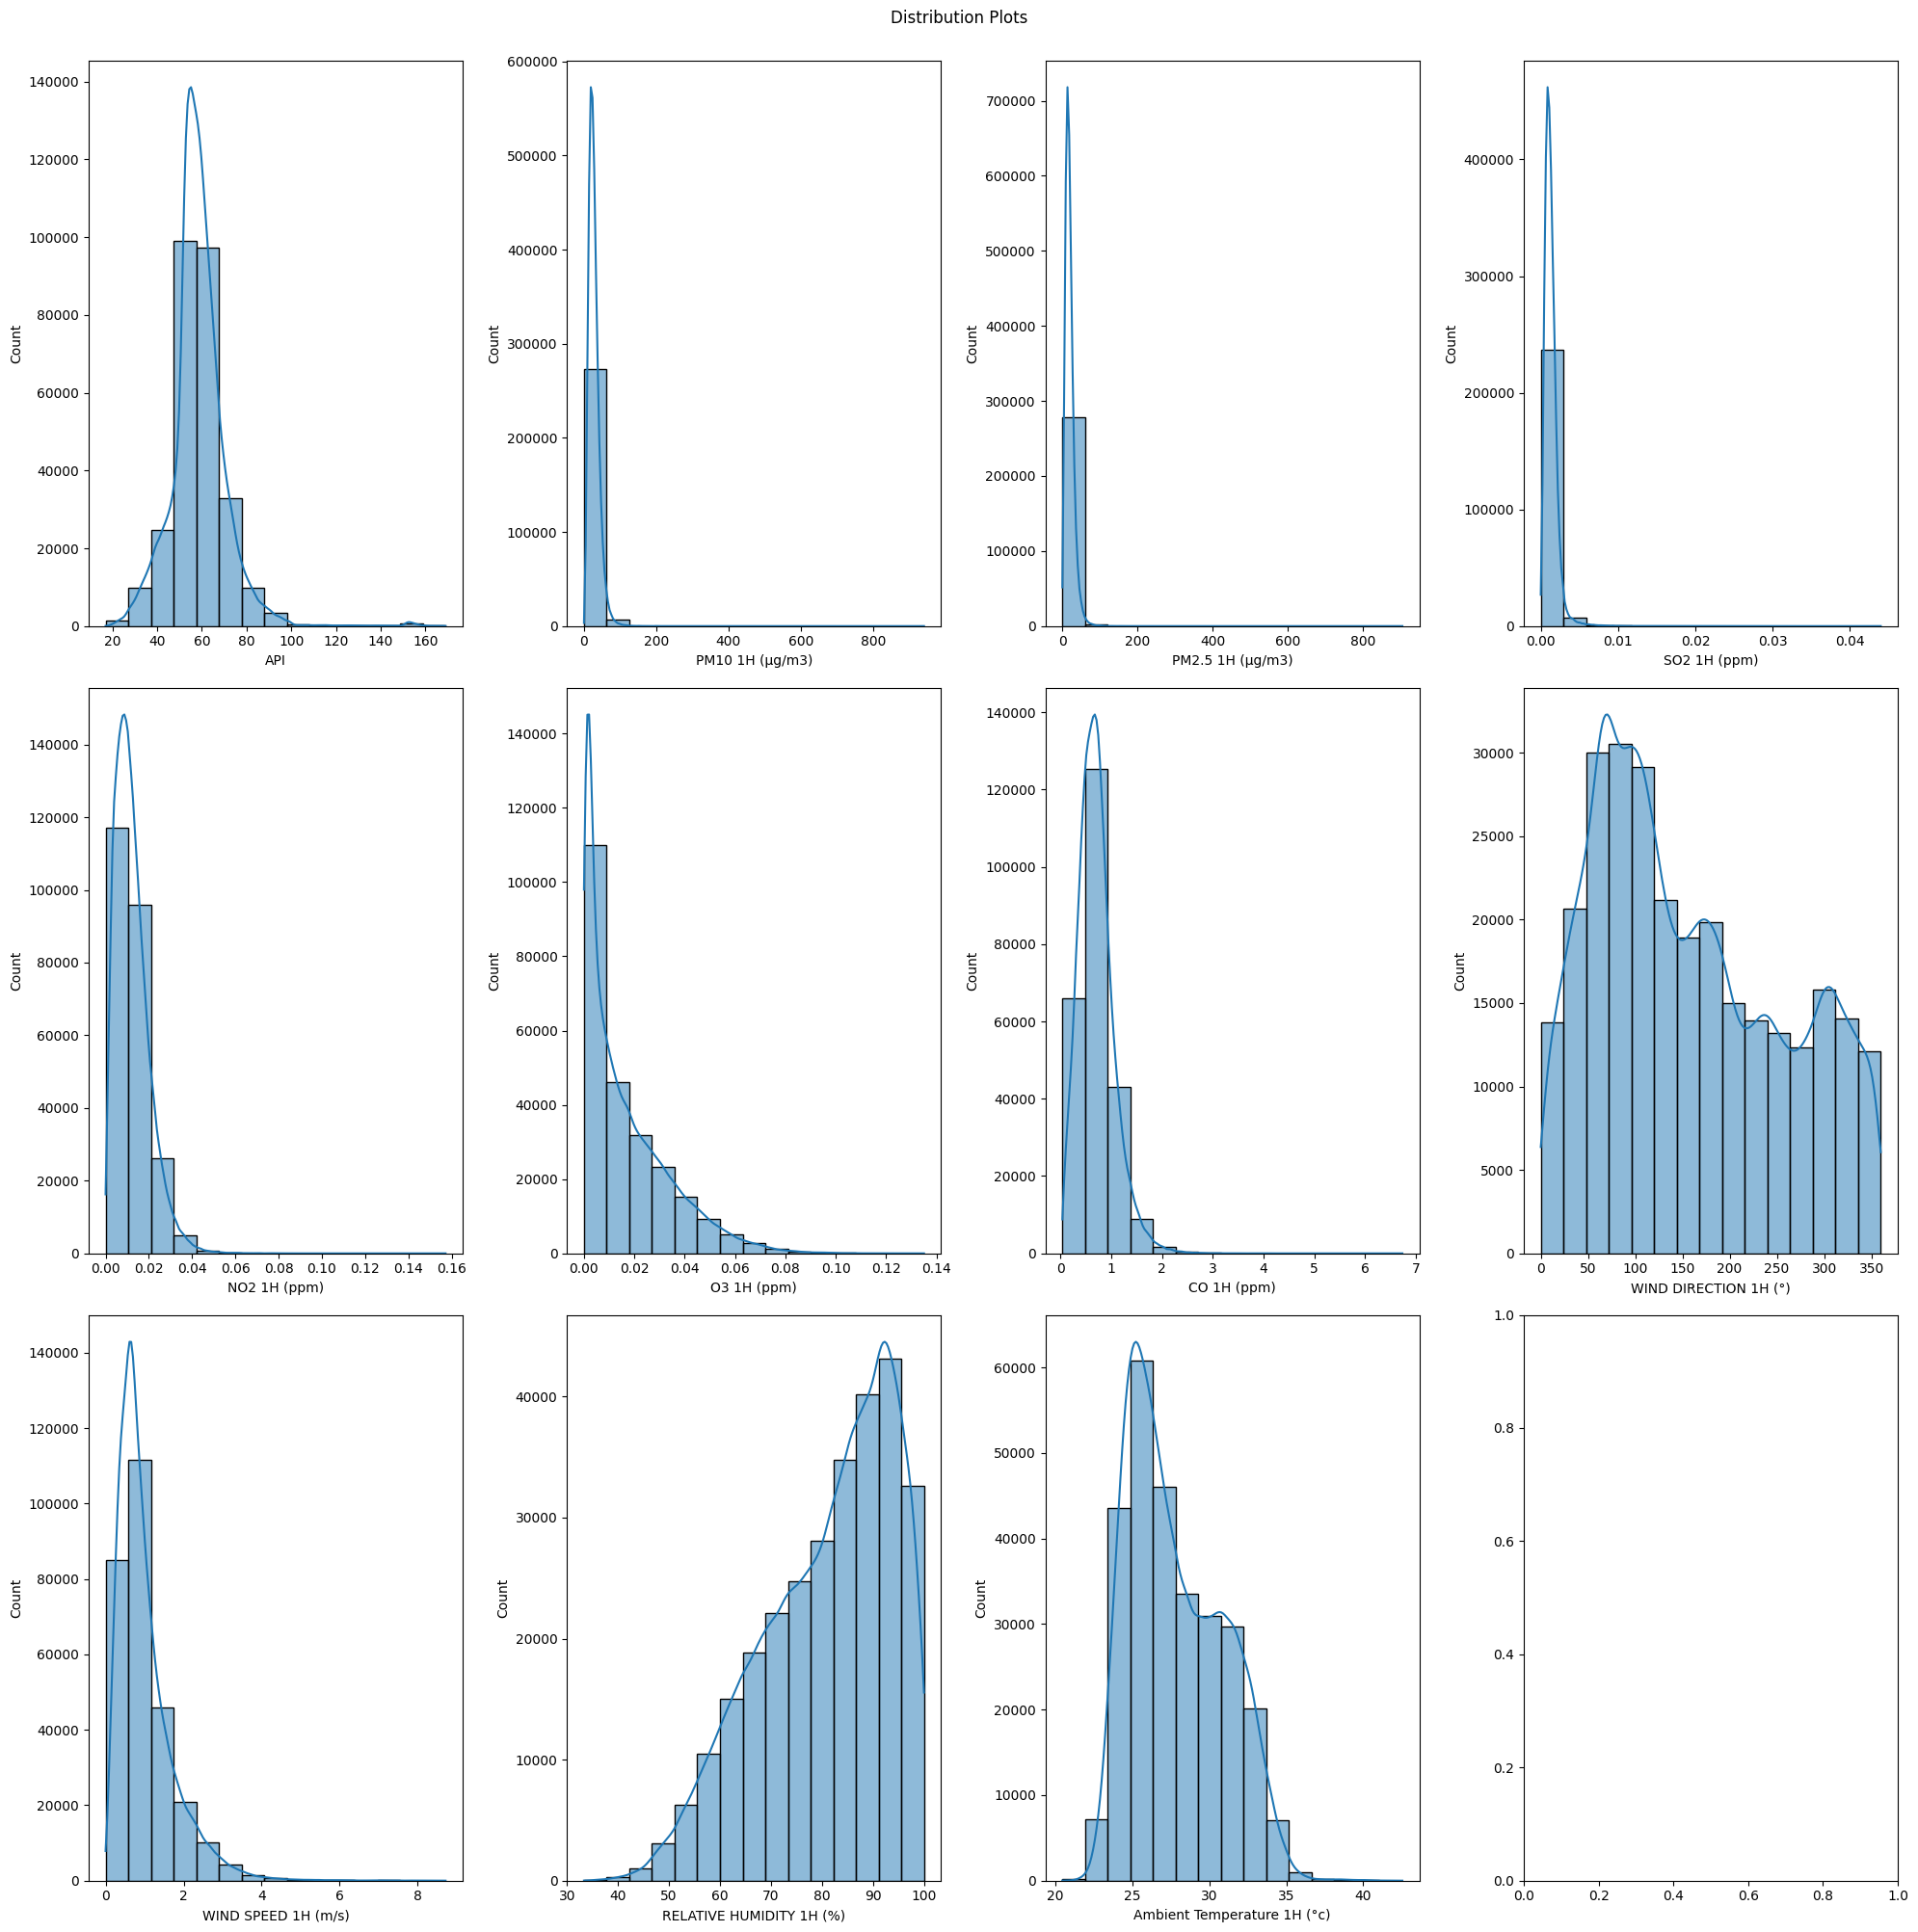

In [3]:
# @title
# Distribution Plots for for Pollutants and Air Conditions

import math
no_of_plots = len(var_sub)
no_of_cols = 4
no_of_rows = math.ceil(no_of_plots / no_of_cols)

fig, axes = plt.subplots(no_of_rows, no_of_cols, figsize=(20, 20))
fig.suptitle('Distribution Plots', y=1)

plot_position = 0
for var in var_sub:
    row_position = plot_position//no_of_cols
    col_position = plot_position%no_of_cols
    X = df[var]
    sns.histplot(X, ax=axes[row_position, col_position], bins=15, kde=True)
    plot_position += 1

plt.tight_layout()    
plt.savefig('../reports/eda/1-distribution_plots.png')  # Save figure to PNG

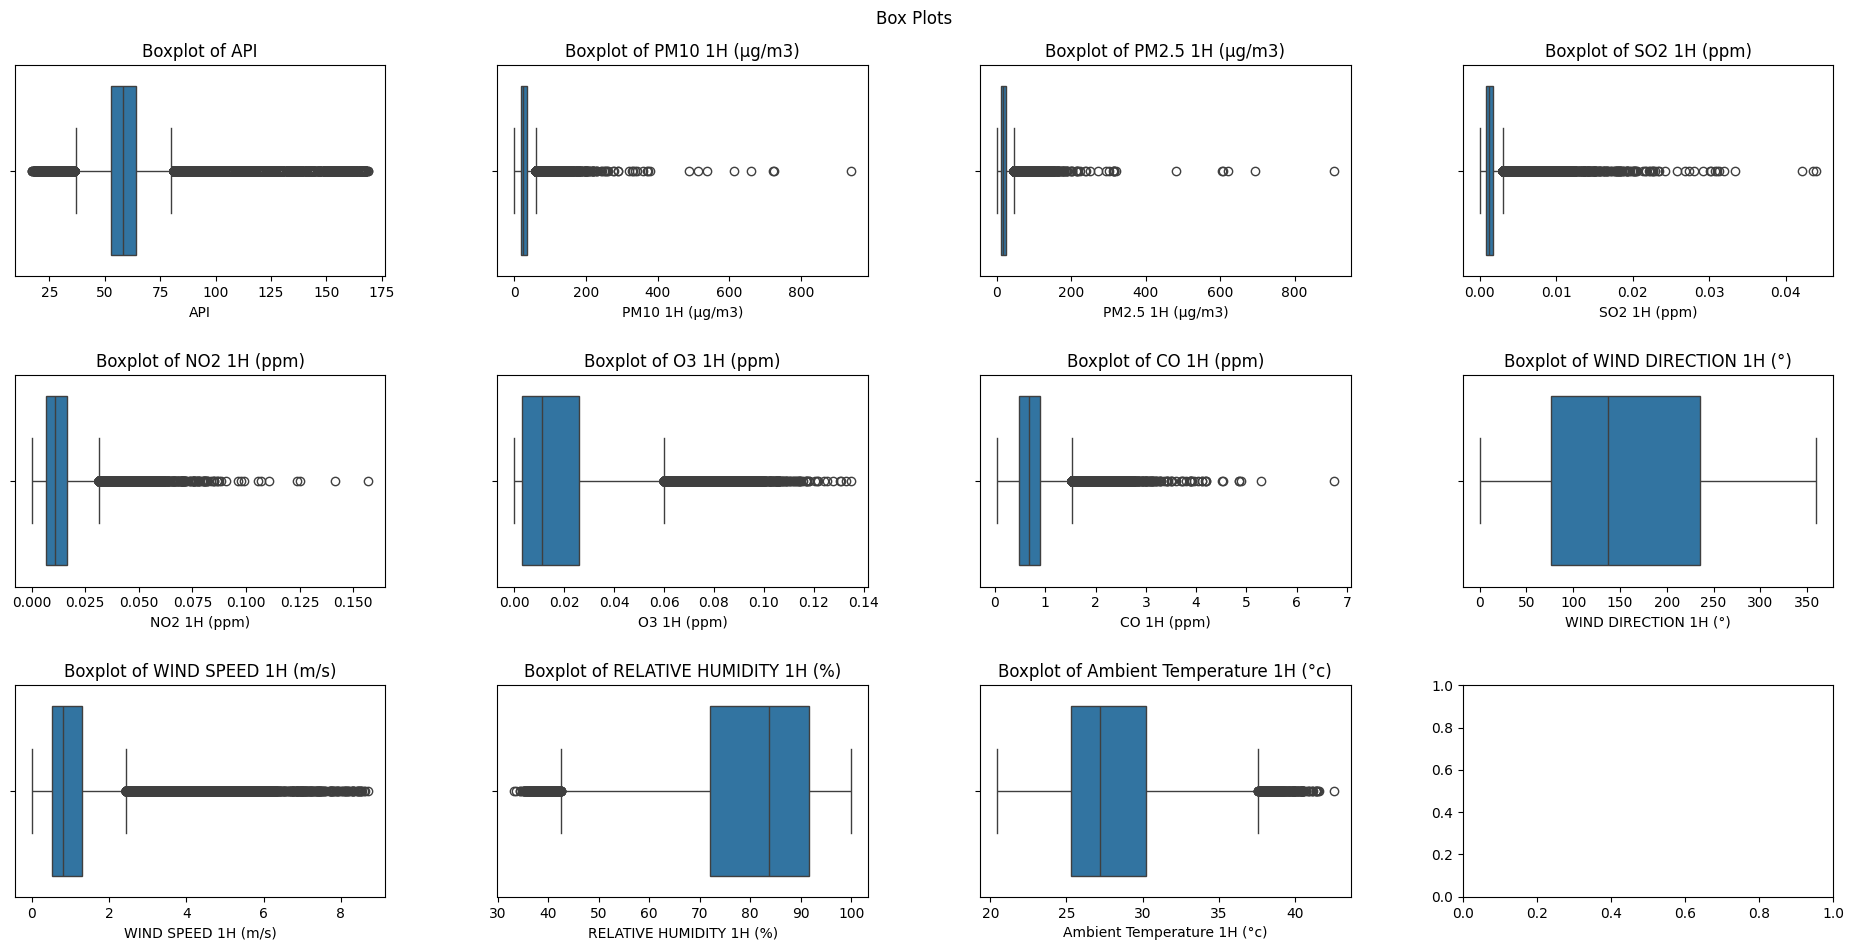

In [4]:
# @title
fig, axes = plt.subplots(no_of_rows, no_of_cols, figsize=(20, 10))
fig.tight_layout(pad=5.0)
fig.suptitle('Box Plots')

for ax, feature in zip(axes.flatten(), df_sub.columns):
    sns.boxplot(x=feature, data=df_sub, ax=ax)
    ax.set_title(f'Boxplot of {feature}')

plt.savefig('../reports/eda/2-boxplot_feature.png')
plt.show()

In [5]:
# @title
# Number of outliers

def outliers(var_name, df):
    # Calculate Q1 and Q3
    Q1 = df[var_name].quantile(0.25)
    Q3 = df[var_name].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Define the bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[var_name] < lower_bound) | (df[var_name] > upper_bound)]

    # Count the number of outliers
    num_outliers = outliers.shape[0]
    return(num_outliers)

print("Number of outliers:\n")
for var in var_sub:
    num_outliers=outliers(var, df)
    print(var+": "+str(num_outliers))

Number of outliers:

API: 20548
PM10 1H (µg/m3): 8216
PM2.5 1H (µg/m3): 9168
SO2 1H (ppm): 7235
NO2 1H (ppm): 6054
O3 1H (ppm): 6020
CO 1H (ppm): 6108
WIND DIRECTION 1H (°): 0
WIND SPEED 1H (m/s): 14211
RELATIVE HUMIDITY 1H (%): 377
Ambient Temperature 1H (°c): 239


### Correlation Analysis

In this project, the strength of the correlation is classified according to the following ranges (Ajayi, 2024):
- Weak: |r|<0.3
- Moderate: 0.3<=|r|<0.7
- Strong: |r|>=0.7

**Correlations between Input Features and the Target Variable (API):**

API exhibits moderate positive correlation with PM10 and PM2.5 at 0.43 and 0.45 respectively. PM10 and PM2.5 are the variables that display the highest correlation with API, indicating that they are key contributors to the API.

**Correlations within Input Features:**
1. PM10 and PM2.5 Redundancy

A strong positive correlation was observed between PM10 and PM2.5 (0.94), suggesting redundancy. However, both were retained in the analysis due to their significant contributions to the Air Pollution Index (API). While PM2.5 poses a greater health risk due to its smaller size, PM10, although larger, still impacts health, particularly in urban settings. Retaining both ensures a more accurate representation of air quality, especially during events like haze, where both types of particulates peak.

2. O3 Correlations

Meanwhile, a strong positive correlation was observed between ambient temperature and O3 concentration at 0.72. This is because O3 levels are formed via photochemical reactions in the presence of sunlight (Sher, 1998).

At the same time, a moderate negative correlation was observed between relative humidity and O3 concentration at -0.68. This suggests that O3 levels decrease during rainy periods, indiciating that rainfall mitigates O3 levels.

It may be worth noting that O3 displays a positive correlation with wind speed (0.32). This contradicts the expectation that there would be lower pollutant concentrations with increased wind speed due to the dispersal of pollutants by wind circulation. (Jin et al., 2024)

However, this observation could be attributed to the strong association observed in previous studies between weather conditions and transport conditions (Bi et al., 2022). Hence, windy conditions may encourage the use of motorised transport, leading to the increased emissions of pollutants that form O3.

3. Pollutant sources

Moderately strong positive correlations are observed between many pollutants:
- NO2 with PM10 and PM2.5 (0.37)
- CO with PM10 and PM2.5 (0.33, 0.34)
- CO and NO2 (0.54)

These correlations indicate that the pollutants likely share common sources, such as vehicular emissions or combustion activities, which emit these pollutants (Ajayi, 2024).

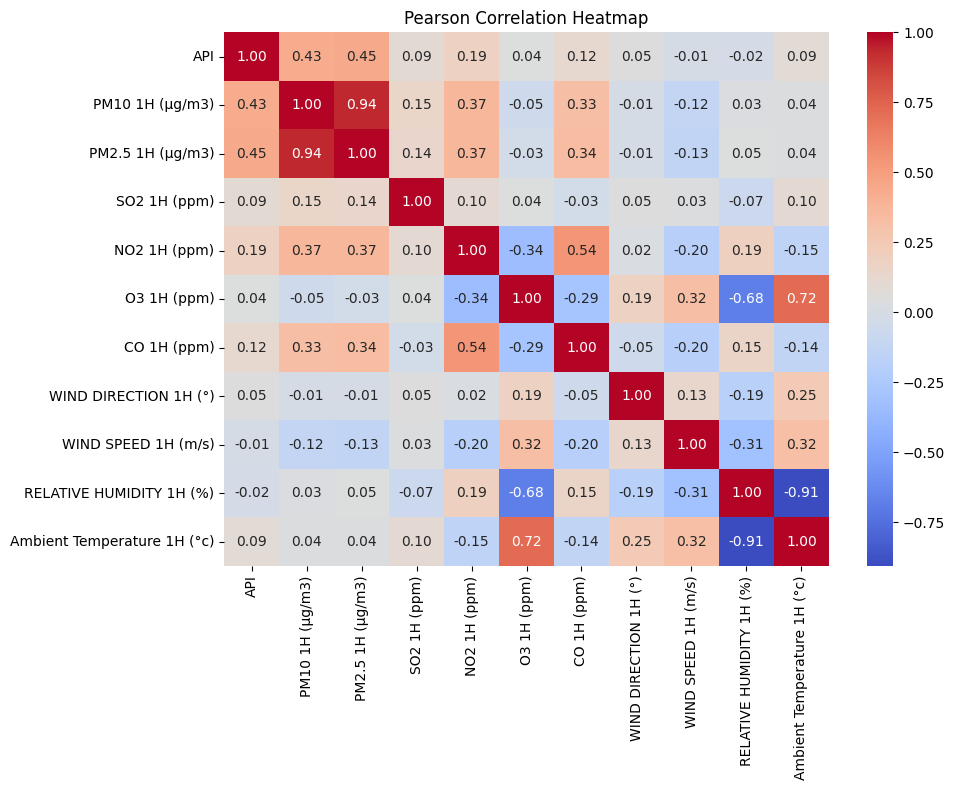

In [6]:
# Create figure and axis explicitly
fig, ax = plt.subplots(figsize=(10, 8))  # You can adjust size as needed
sns.heatmap(df_sub.corr(), annot=True, cmap="coolwarm", fmt='.2f', ax=ax)
ax.set_title('Pearson Correlation Heatmap')  # Set title using ax
fig.tight_layout()  # Apply layout adjustments to the correct fig
fig.savefig('../reports/eda/3-pearson-correlation-heatmap.png', dpi=300)
plt.show()

### Time-Series Analysis

Under the time-series analysis section, three main analysis were done:
- Rolling Average Time Series Plot
- Monthly and Yearly Aggregation
- Heatmap for Hourly API by Day of Week

#### Rolling Average Time Series Plot

A rolling average of 7 days was used to smooth out short-term fluctuations and reveal longer-term trends in API levels. The following trends were observed:
1. A sharp dip in API around May 2020:

A significant drop in the API occurred around May 2020, which coincides with the initial implementation of the Movement Control Order (MCO) in the Klang Valley. This period also saw heavier rainfall and precipitation from March to May, which may have contributed to the reduction in pollutants (Weather Spark, 2024).

2. Increased spikes in 2023

In 2023, more frequent and drastic spikes in API levels were observed, particularly in September. These sharp increases in air quality index (API) levels were largely due to massive land and forest fires in Sumatra and Kalimantan, Indonesia. The fires occurred during the southwest monsoon period, which, combined with the El Niño effect, led to a prolonged drought across Southeast Asia (Hansen, 2023).

After several years of relatively mild fire seasons since 2019, the fires in Indonesia in 2023 burned approximately 267,900 hectares (662,000 acres) by October 2, surpassing the total area burned in 2022 (Strangio, 2023).

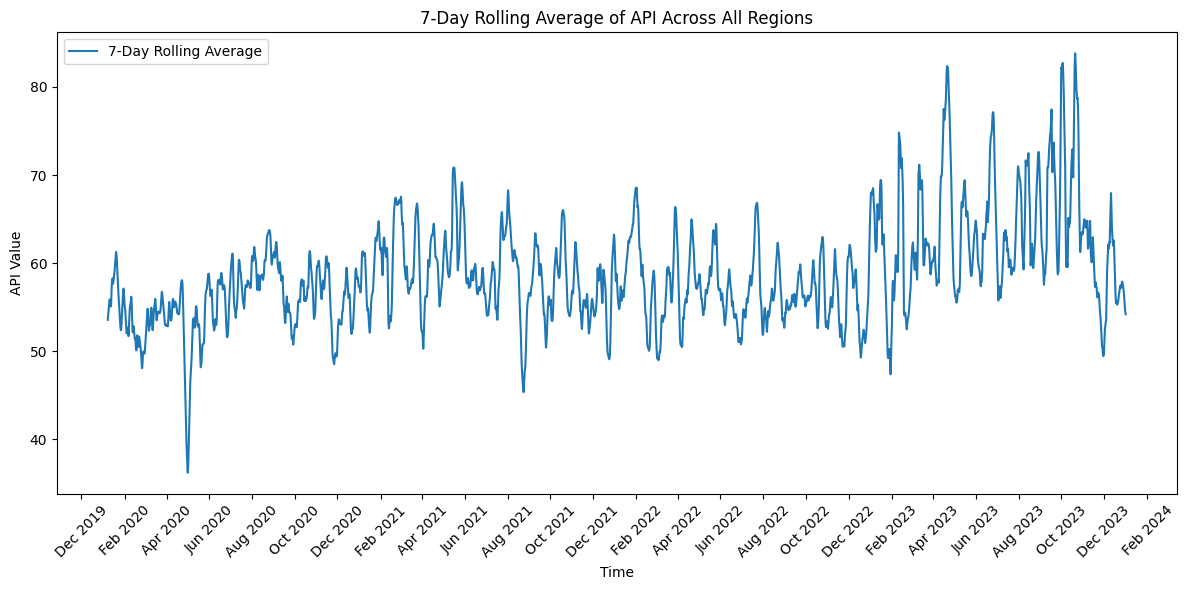

In [7]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  # Import this for date formatting

# Assuming df contains the timestamp, API values, and locations
# Ensure the 'DATE TIME' column is a datetime object and set it as the index
df['DATE TIME'] = pd.to_datetime(df['DATE TIME'])
df.set_index('DATE TIME', inplace=True)

# Aggregate data by averaging the API values for each timestamp (if multiple locations exist)
df_avg = df.groupby(df.index).agg({'API': 'mean'})

# Calculate the 7-day rolling average
rolling_avg = df_avg['API'].rolling(window=168).mean()  # 168 hours = 7 days

plt.figure(figsize=(12, 6))

# Plot the rolling average with the correct x-axis (dates)
plt.plot(rolling_avg.index, rolling_avg, label='7-Day Rolling Average')

# Add title and labels
plt.title('7-Day Rolling Average of API Across All Regions')
plt.xlabel('Time')
plt.ylabel('API Value')

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45)

# Set date format and interval for x-axis
loc = mdates.MonthLocator(interval=2)
plt.gca().xaxis.set_major_locator(loc)
fmt = mdates.DateFormatter('%b %Y')
plt.gca().xaxis.set_major_formatter(fmt)

# Display the legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.savefig('../reports/eda/4-seven-day-API-all.png')
plt.show()

df = df.reset_index()


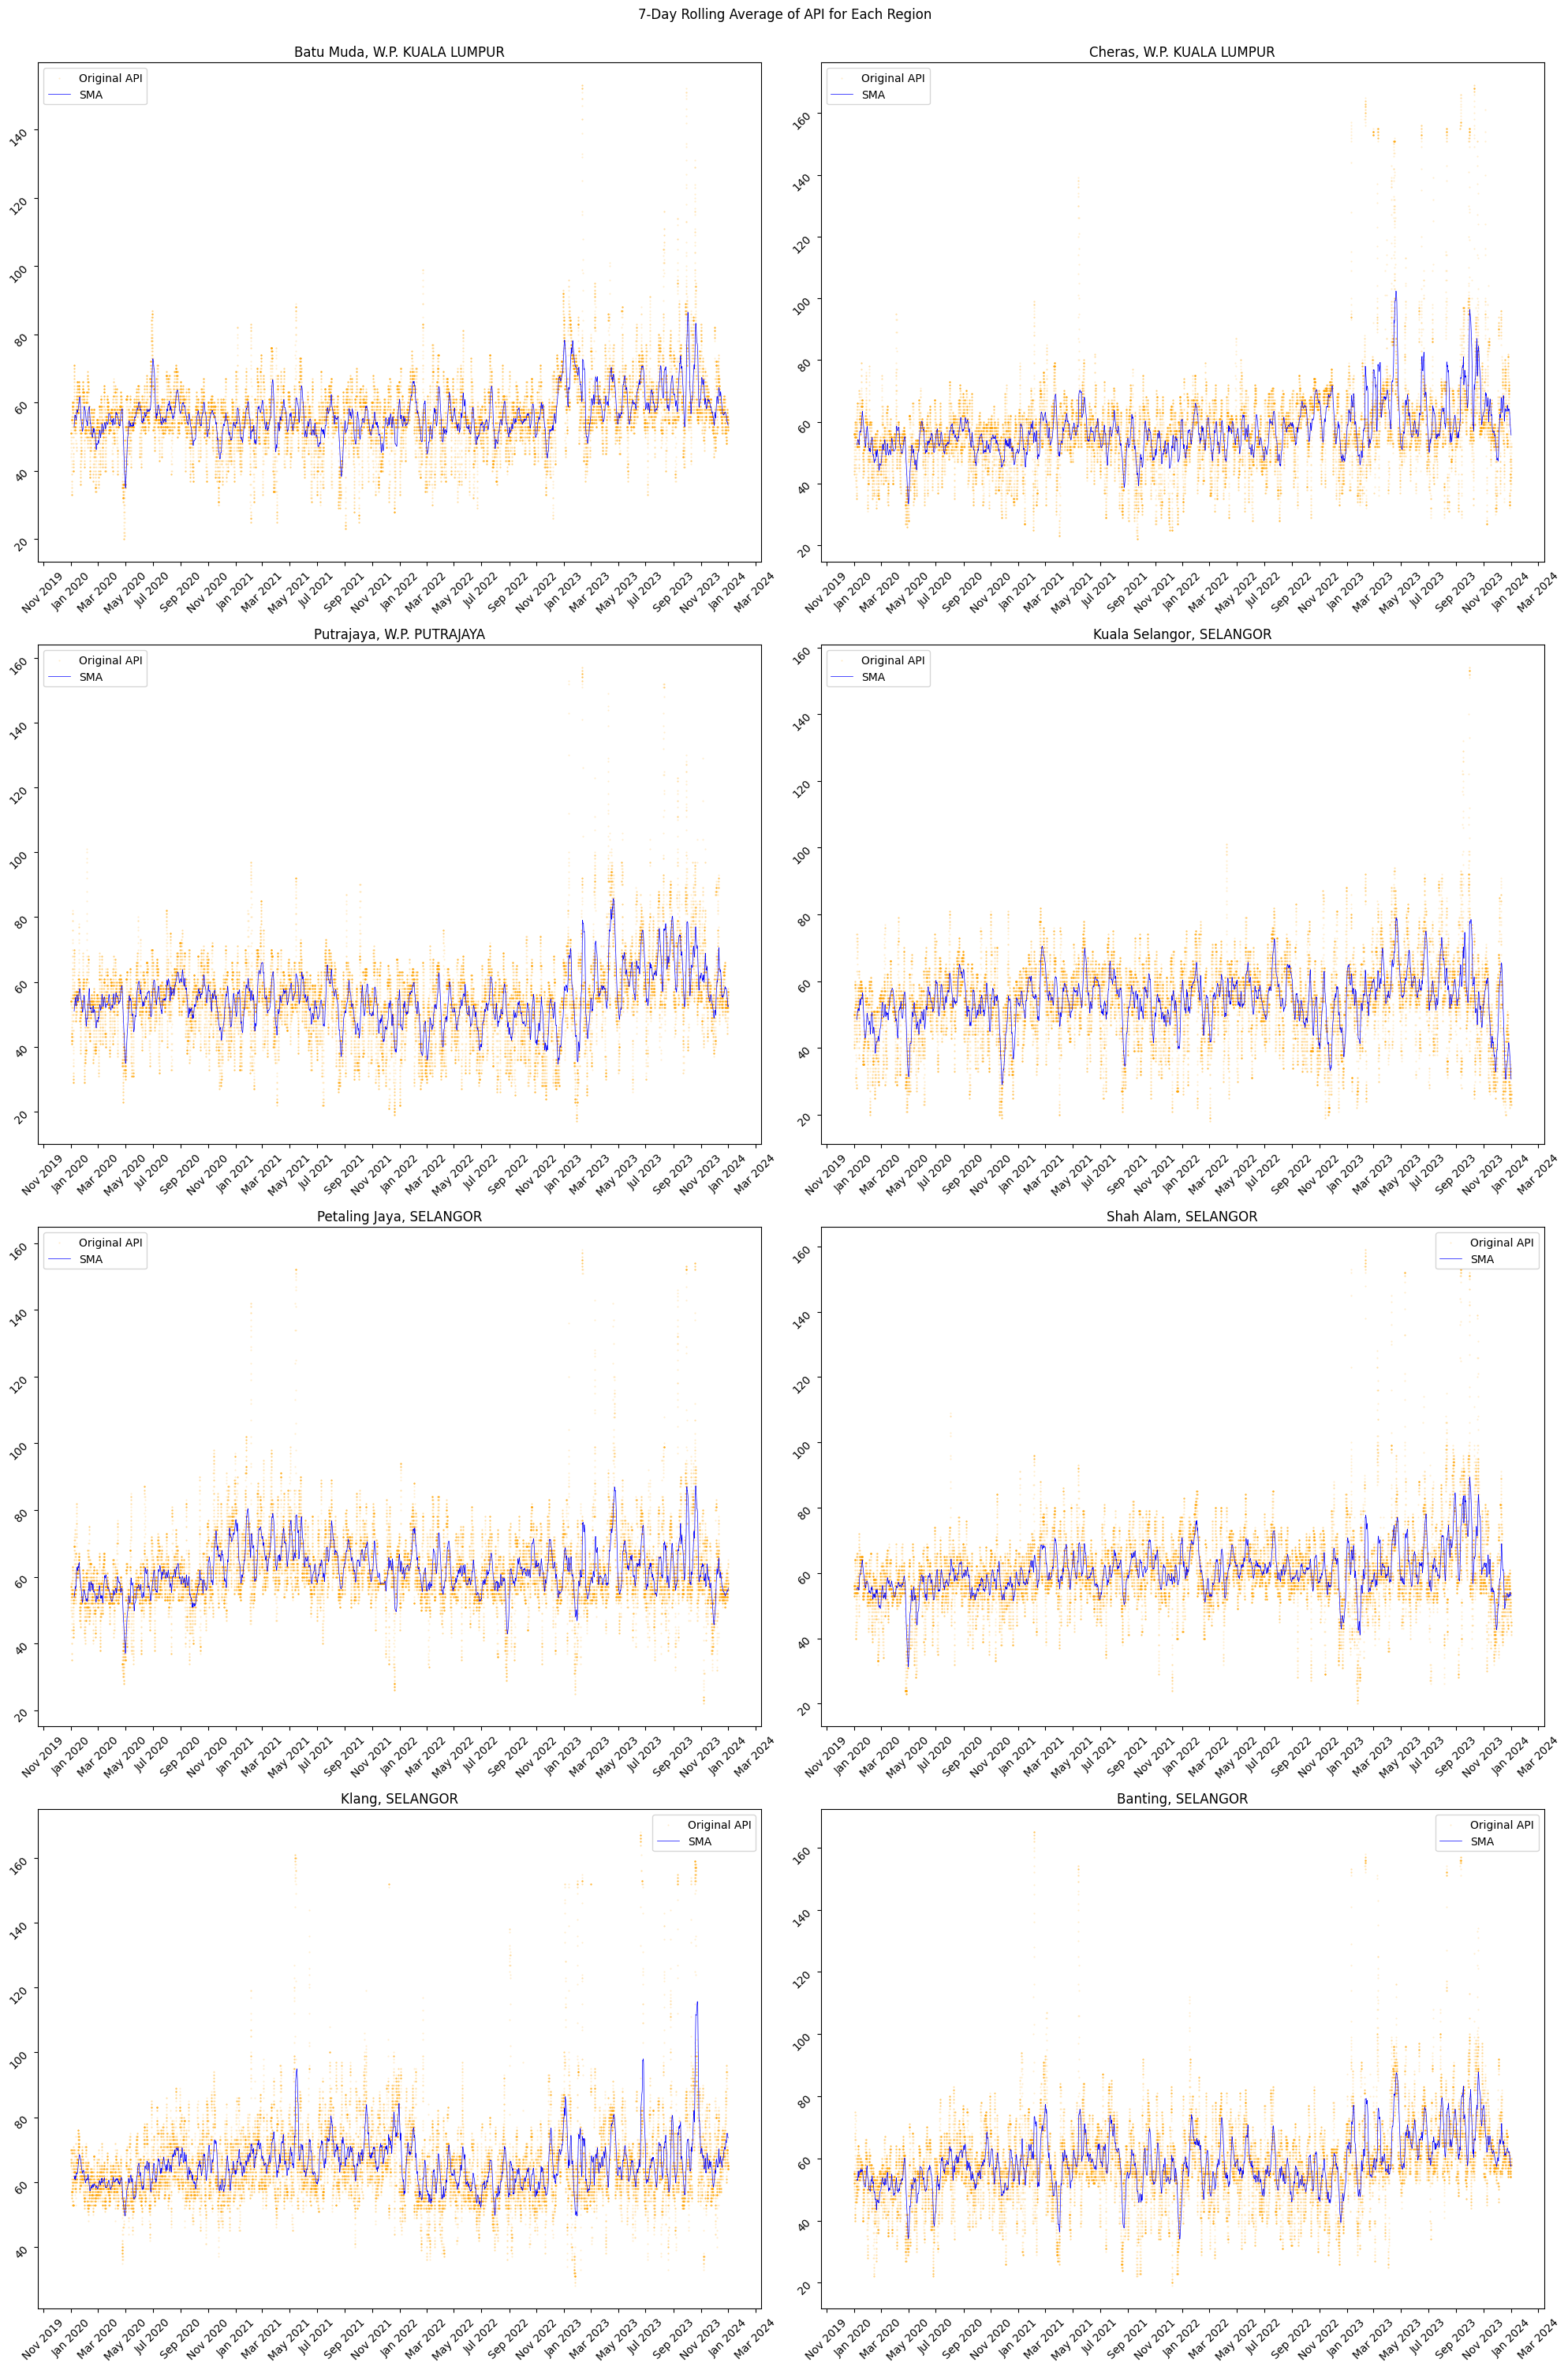

In [8]:
# @title
import matplotlib.dates as mdates

# Setting the 'DATE TIME' column as the index of the DataFrame
df = df.set_index('DATE TIME')

# Ensuring that the index is of datetime type
df.index = pd.to_datetime(df.index)

# Split data set
unique_locations = df['LOCATION'].unique()
window_size = 24*7  # Window size defined to be 7 days

df_api = {}
for unique_location in unique_locations:
    df_api[unique_location] = df['API'][df['LOCATION']==unique_location]

df_api_sma = {}
for unique_location in unique_locations:
    df_api_sma[unique_location] = df['API'][df['LOCATION']==unique_location].rolling(window=window_size).mean()

no_of_plots = len(unique_locations)
no_of_cols = 2
no_of_rows = math.ceil(no_of_plots / no_of_cols)

fig, axes = plt.subplots(no_of_rows, no_of_cols, figsize=(20, 30))
fig.suptitle('7-Day Rolling Average of API for Each Region', y=1.0)

plot_position = 0
for unique_location in unique_locations:
    row_position = plot_position//no_of_cols
    col_position = plot_position%no_of_cols
    # Plot original data
    axes[row_position, col_position].scatter(df_api[unique_location].index, df_api[unique_location], label='Original API', marker="x", s=0.3, c="orange", alpha=0.2)
    # Plot SMA
    axes[row_position, col_position].plot(df_api_sma[unique_location], label='SMA', linewidth=0.5, color='blue')
    axes[row_position, col_position].title.set_text(unique_location)
    axes[row_position, col_position].legend()
    # # Create custom ticks using matplotlib date tick locator and formatter
    loc = mdates.MonthLocator(interval=2)
    axes[row_position, col_position].xaxis.set_major_locator(loc)
    fmt = mdates.DateFormatter('%b %Y')
    axes[row_position, col_position].xaxis.set_major_formatter(fmt)
    axes[row_position, col_position].tick_params(labelrotation=45)
    plot_position += 1

df = df.reset_index()
plt.tight_layout()
plt.savefig('../reports/eda/5-seven-day-API-individual.png')

#### Monthly and Yearly Aggregation
1. Monthly Trends:
- The years 2021 and 2022 exhibited similar monthly trends, with peaks observed in May, July, and October.
- In 2023, the API was consistently higher across all months except January, February, and May, which could reflect a combination of seasonal variations and increased pollution levels due to various sources like fires and industrial emissions.
2. MCO Impact on 2020:
- The low API values observed at the beginning of 2020 can be attributed to the enforcement of the MCO, which led to the suspension of many industrial activities and reduced vehicular traffic.

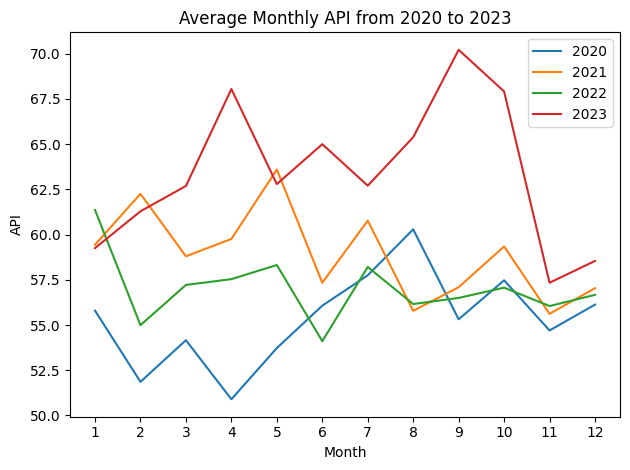

In [9]:
# @title
from enum import unique
df_seasonal = df[['Year','Month','Month_Year','API']].groupby(['Month_Year']).mean()

unique_years = df['Year'].unique()

fig, ax = plt.subplots()

for unique_year in unique_years:
  X = df_seasonal[df_seasonal['Year']==unique_year][['Month']]
  Y = df_seasonal[df_seasonal['Year']==unique_year][['API']]
  plt.plot(X,Y)
  plt.legend(unique_years)
  plt.xlabel('Month')
  plt.ylabel('API')
  plt.title('Average Monthly API from 2020 to 2023')
  plt.xticks(range(1, 13))

plt.tight_layout()  
plt.savefig('../reports/eda/6-average-monthly-API.png')

#### Hourly API by Day of Week

To identify patterns in air quality over different days in a typical week, the following graphs were created:
- Hourly API by Day of Week (Heatmap)
- Hourly Pollutant Concentration and Weather Conditions by Day of Week (Heatmap)

A heatmap of traffic congestion in Kuala Lumpur obtained from an external is also attached below to support this analysis (TomTom Traffic Index, 2024).

**Heatmap Hourly API by Day of Week**

Several key observations were made from the hourly heatmap of the Air Pollutant Index (API):

1. Gradual increase in API from Tuesday evening to Friday night

The steady increase in API values can be attributed to rising traffic volumes and industrial emissions as the workweek progresses. Traffic peaks, especially around 8 am and 6 pm (as shown in the traffic heatmap), lead to higher pollutant concentrations, causing the gradual increase in API levels.

2. Steady API decrease over the weekend

Steady decrease in API values was obverved over the weekend. Due to lower traffic volumes on Saturdays and Sundays, the air quality improved during the weekend. This leads to the lowest API values on Tuesdays, particularly in the morning hours.

3. Absence of sharp peaks

The absence of sharp daily peaks in the API heatmap compared to pollutants like PM10 or NO2 can be attributed to the way API is calculated by JAS. The API aggregates pollutant concentrations, which are averaged over different periods (e.g., 1-hour for NO2 and CO, 8-hour for Ozone, and 24-hour for PM10 and PM2.5) (Jabatan Alam Sekitar Malaysia, 2023). This averaging smoothens fluctuations, resulting in steady increases and decreases in API values. This reflects the cumulative effect of pollutant concentrations rather than sharp peaks during rush hours.

**Heatmap of other Variables  by Day of Week**

Several key observations were made from the hourly heatmap of other variables:

1. Pollutants PM10, PM2.5, NO2, and CO show peaks around 9-10 am in the morning and 12 am (midnight)

The first peak in the morning likely orginiates from the morning rush hour traffic. Meanwhile lower pollution concentrations in the afternoon can be attributed to lower traffic activtiies and increased mixing height. Meanwhile, the second peak at night is likely caused by the evening rush hour, lower wind speeds, and lowering of the mixing layer as the temperature cools (Ahmad Mohtar et al., 2022).

2. SO2 peaks around 12 pm, while Ozone peaks around 3 pm

The peak of Ozone (O3) at 3pm is due to its photochemical formation being enhanced by the higher level of UV radiation in the afternoon (Abdul Halim et al., 2018). Meanwhile, the SO2 patterns may be linked to atmospheric conditions such as temperature, sunlight, and industrial emissions.

3. At 3 pm, wind speed and ambient temperature are highest while relative humidity is lowest.

These factors affect how pollutants disperse. For example, higher wind speeds may lead to better dispersion, reducing pollutant concentrations, while lower humidity may allow particulate matter to remain suspended, potentially increasing the concentration of pollutants and the API.

The figure records the hourly travel time per 10km in Kuala Lumpur, reflecting traffic conditions at different hours and days  (TomTom Traffic Index, 2024).

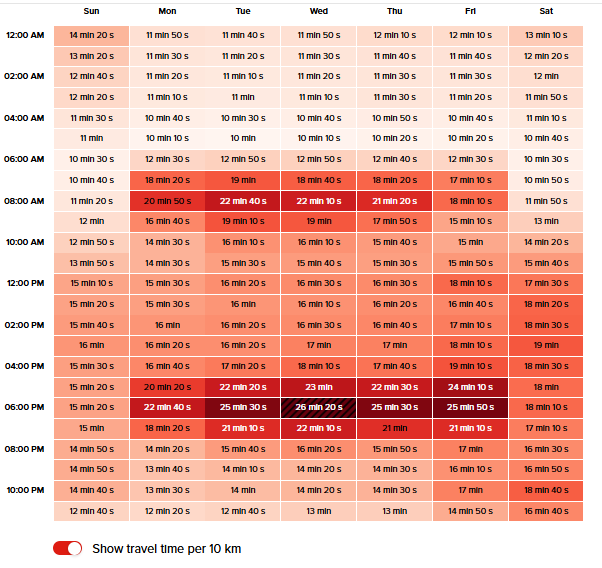

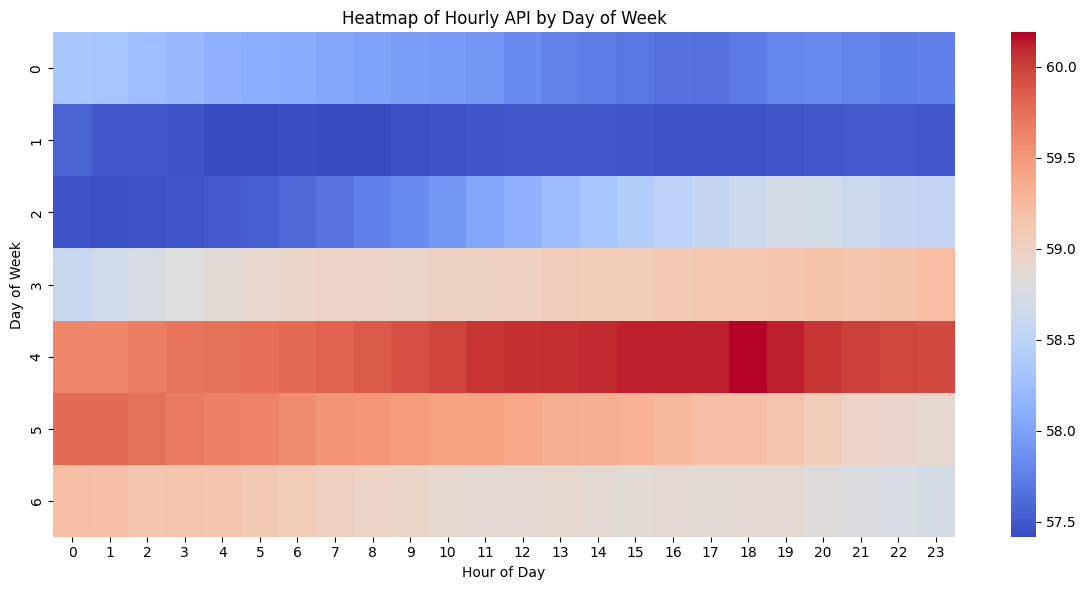

In [10]:
# @title
api_heatmap = df.pivot_table(values='API', index='DayOfWeek', columns='Hour', aggfunc='mean')

plt.figure(figsize=(12, 6))
sns.heatmap(api_heatmap, cmap='coolwarm', annot=False)
plt.title('Heatmap of Hourly API by Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig('../reports/eda/7-heatmap-hourly-API-by-dayofweek.png')
plt.show()


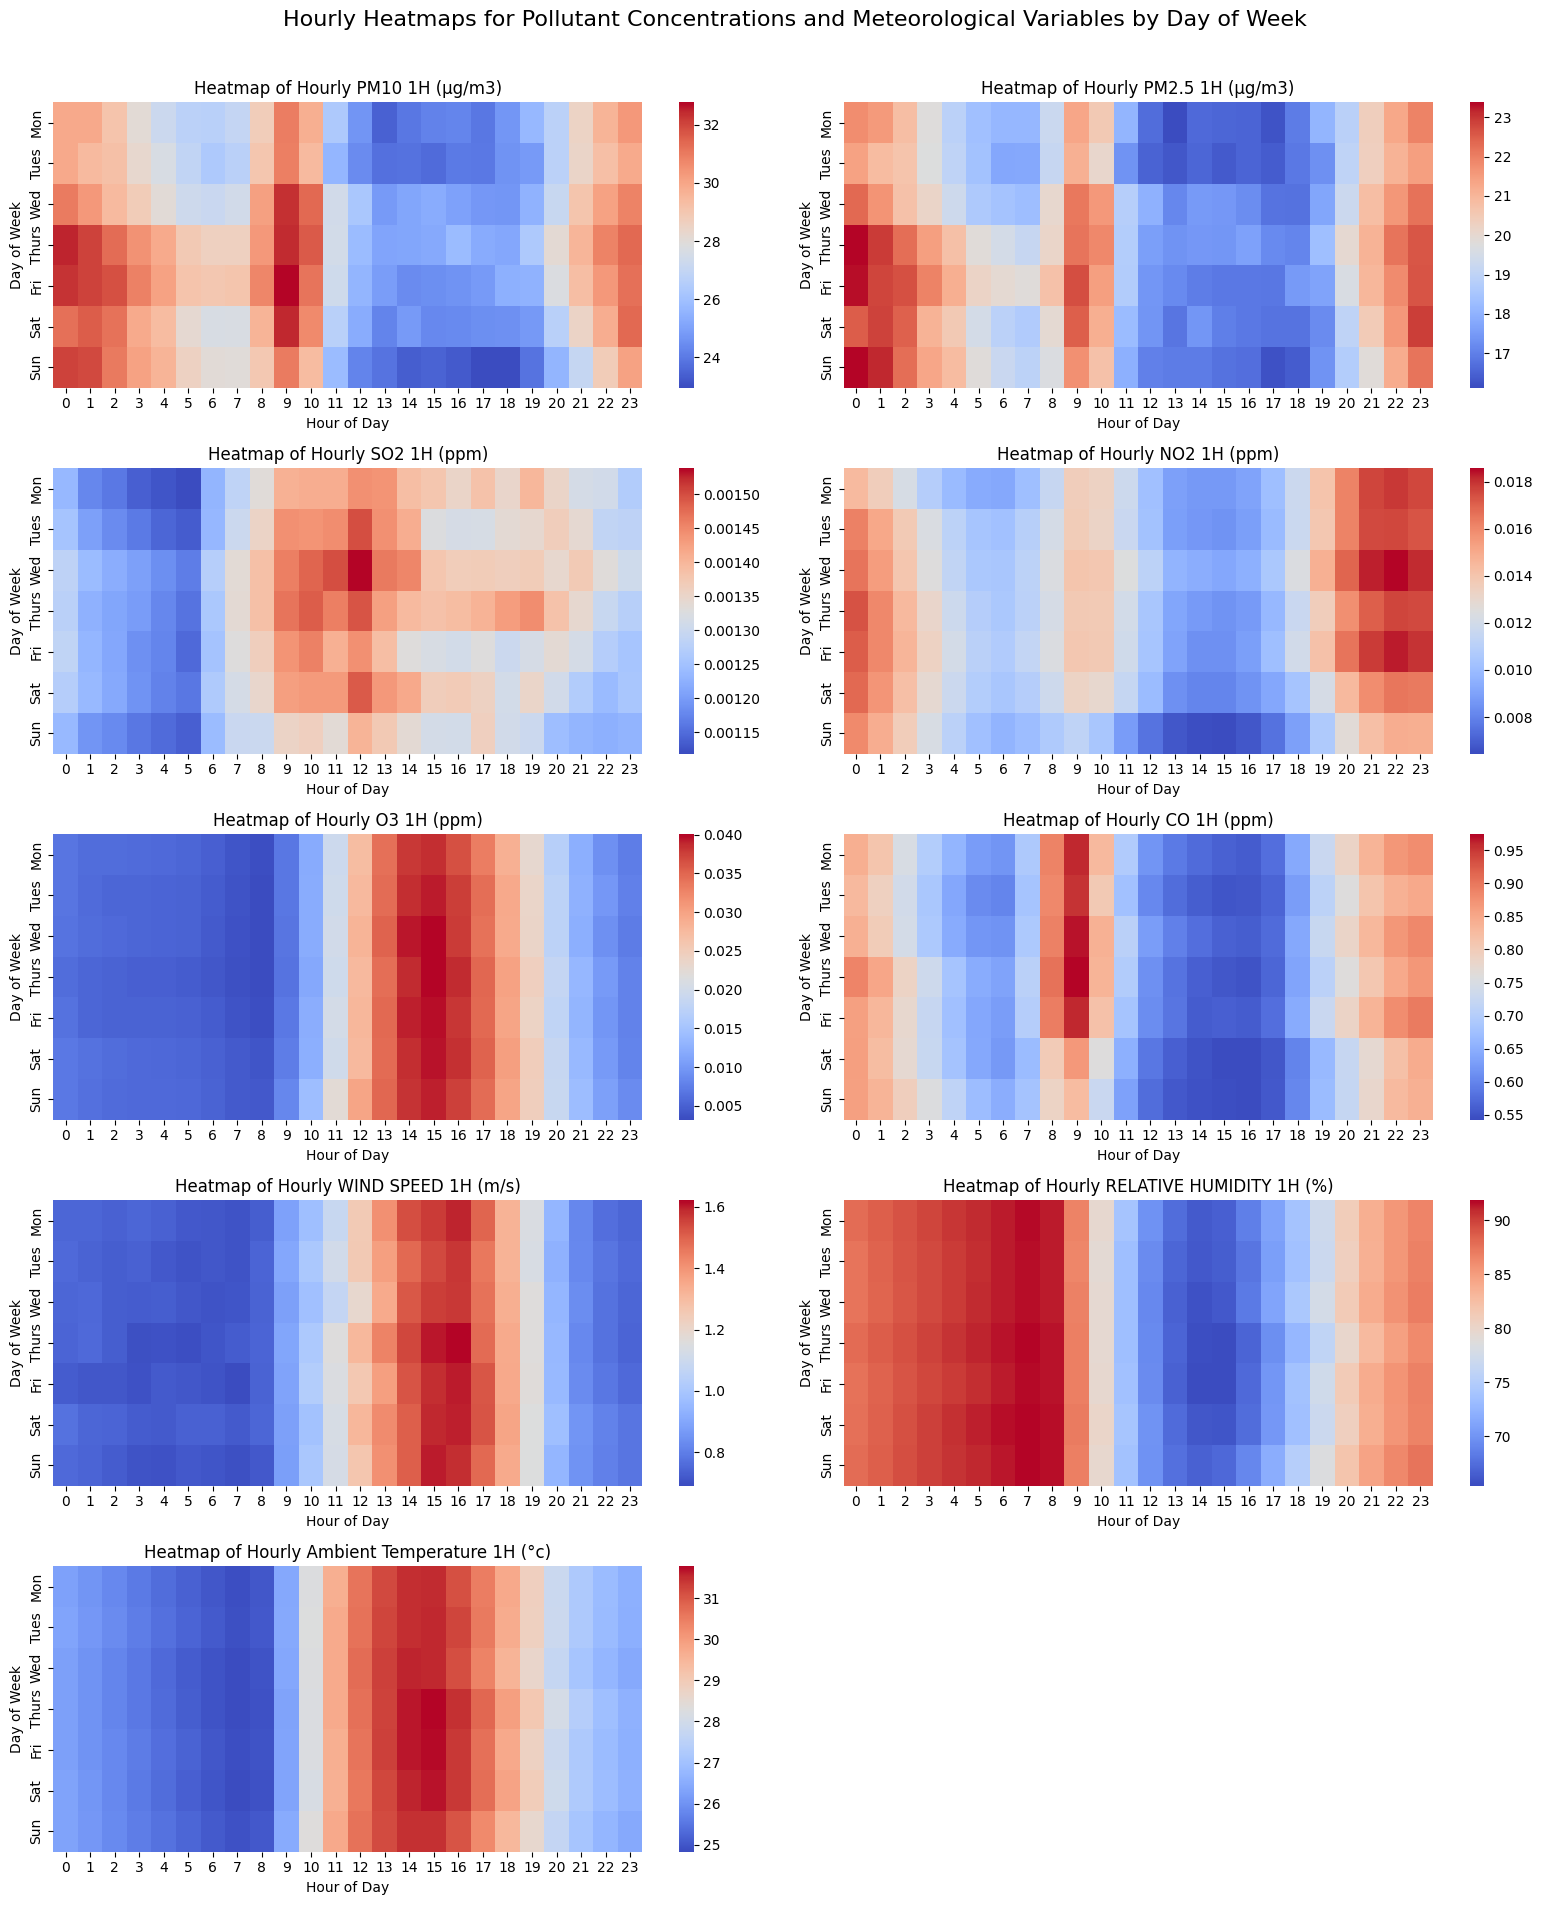

In [11]:
# @title
# Mapping numeric day values to day names
day_map = {0: 'Mon', 1: 'Tues', 2: 'Wed', 3: 'Thurs', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

# Filter out the 'WIND DIRECTION 1H (°)' column
columns_to_plot = [col for col in df_sub.columns if col != 'WIND DIRECTION 1H (°)' and col != 'API']

# Number of variables to plot
num_vars = len(columns_to_plot)
num_cols = 2  # Number of columns for subplots
num_rows = math.ceil(num_vars / num_cols)  # Calculate required rows

fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4 * num_rows))
fig.suptitle('Hourly Heatmaps for Pollutant Concentrations and Meteorological Variables by Day of Week', y=0.95, fontsize=16)

# Flatten axes array for easier indexing
axes = axes.flatten()

# Loop through filtered columns and create a heatmap
for idx, hmvar in enumerate(columns_to_plot):
    api_heatmap = df.pivot_table(values=hmvar, index='DayOfWeek', columns='Hour', aggfunc='mean')

    # Replace numeric day values with day names in the pivot table index
    api_heatmap.index = api_heatmap.index.map(day_map)

    sns.heatmap(api_heatmap, cmap='coolwarm', annot=False, ax=axes[idx])
    axes[idx].set_title(f'Heatmap of Hourly {hmvar}')
    axes[idx].set_xlabel('Hour of Day')
    axes[idx].set_ylabel('Day of Week')

# Hide any unused subplots
for idx in range(num_vars, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout(rect=[0, 0, 1, 0.94])  # Adjust layout to fit title
plt.savefig('../reports/eda/8-hourly-heatmap-pollutant-weather-by-dayofweek.png')
plt.show()

In [12]:
# Save as csv
df.to_csv('../data/interim/preprocessed_df2.csv',index = False)